# Stock Price Trend Prediction: Chapter 2C

## Final Evaluation, Threshold Optimisation & Model Analysis

<br>

This notebook performs the **final, one-time evaluation** on the held-out test set (2023 → 2025).
This set has been untouched until now. It performs **five major tasks**:

1. **Load** the trained model, test arrays, and all metadata
2. **Test set evaluation** — unbiased performance metrics
3. **Threshold optimisation** — find the best decision boundary beyond 0.5
4. **Temporal analysis** — performance across different market regimes
5. **Feature importance** — gradient-based saliency to understand model focus

<br>

> ⚠️ **Rule:** The test set is evaluated exactly once. Do not re-run this notebook
> repeatedly with different thresholds — that constitutes test set leakage.
> All threshold decisions must be made on the **validation set** first (Part C),
> then applied once to the test set (Part D).


### Part A: Imports & Load All Artifacts


In [21]:
# ============================================================
#  A1 — Imports
# ============================================================

import os
import pickle
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    f1_score, accuracy_score, roc_auc_score
)

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
tf.random.set_seed(42)

# ── Register TemporalAttention so Keras can deserialize the saved model ──
# This must be defined and decorated BEFORE load_model is called.
# The decorator registers it in Keras's global custom object registry.

@tf.keras.utils.register_keras_serializable()
class TemporalAttention(tf.keras.layers.Layer):
    """Bahdanau-style attention over LSTM timestep outputs."""

    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attn_W', shape=(input_shape[-1], self.units),
            initializer='glorot_uniform', trainable=True
        )
        self.b = self.add_weight(
            name='attn_b', shape=(self.units,),
            initializer='zeros', trainable=True
        )
        self.v = self.add_weight(
            name='attn_v', shape=(self.units,),
            initializer='glorot_uniform', trainable=True
        )

    def call(self, inputs):
        score = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        attention_weights = tf.nn.softmax(
            tf.tensordot(score, self.v, axes=[[-1], [0]]), axis=1
        )
        context = tf.reduce_sum(
            inputs * tf.expand_dims(attention_weights, -1), axis=1
        )
        return context

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

print(f'✅ Imports ready   (TF {tf.__version__})')
print(f'   TemporalAttention registered for model loading')

✅ Imports ready   (TF 2.21.0)
   TemporalAttention registered for model loading


In [23]:
# ============================================================
#  A2 — Load Model & All Artifacts
# ============================================================

DATA_DIR  = "./data"
MODEL_DIR = "./model"

# ── Load model ──────────────────────────────────────────────
# custom_objects is a safety net in case the registry decorator
# isn't sufficient in some Keras versions. Both mechanisms
# together guarantee TemporalAttention is always found.
model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, 'final_model.keras'),
    custom_objects={'TemporalAttention': TemporalAttention}
)
print('✅ Model loaded from Chapter 2B')

# ── Load test arrays ────────────────────────────────────────
def _load(base, fname):
    return np.load(os.path.join(base, fname))

X_test  = _load(DATA_DIR, 'X_test.npy').astype(np.float32)
y_test  = _load(DATA_DIR, 'y_test.npy').astype(np.float32)
X_val   = _load(DATA_DIR, 'X_val.npy').astype(np.float32)
y_val   = _load(DATA_DIR, 'y_val.npy').astype(np.float32)

# ── Load metadata ───────────────────────────────────────────
with open(os.path.join(DATA_DIR, 'preprocessing_meta.pkl'), 'rb') as f:
    meta = pickle.load(f)

with open(os.path.join(DATA_DIR, 'feature_cols.pkl'), 'rb') as f:
    FEATURE_COLS = pickle.load(f)

with open(os.path.join(MODEL_DIR, 'training_config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

with open(os.path.join(MODEL_DIR, 'training_history.pkl'), 'rb') as f:
    train_hist = pickle.load(f)

val_predictions = np.load(os.path.join(MODEL_DIR, 'val_predictions.npy'))

HP          = cfg['hyperparameters']
WINDOW_SIZE = meta['window_size']
N_FEATURES  = meta['n_features']
BATCH_SIZE  = HP['BATCH_SIZE']

print(f'✅ All artifacts loaded!')
print(f'\n   X_test  shape : {X_test.shape}')
print(f'   y_test  shape : {y_test.shape}')
print(f'   Test range    : {meta["test_date_range"]}')
print(f'   Best Val AUC  : {cfg["best_val_auc"]:.4f}')
print(f'   Best epoch    : {cfg["best_epoch"]}')

✅ Model loaded from Chapter 2B
✅ All artifacts loaded!

   X_test  shape : (510, 30, 16)
   y_test  shape : (510,)
   Test range    : ('2023-01-03', '2025-03-14')
   Best Val AUC  : 0.5495
   Best epoch    : 15


### Part B: Generate Test Set Predictions


✅ Inference complete!

   y_test_prob — shape: (510,)
   Range       : [0.3265, 0.7505]
   Mean prob   : 0.4691  (UP bias check)


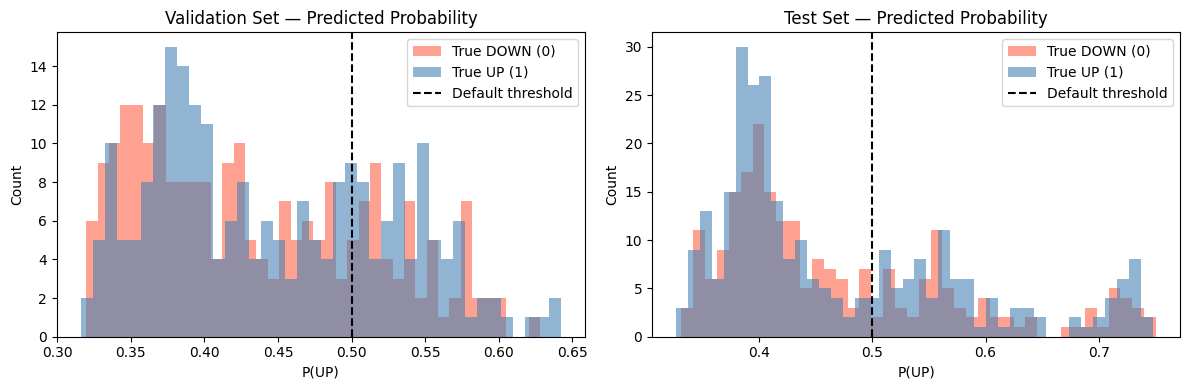

💾 Saved → predicted_probability_distributions.png


In [24]:
# ============================================================
#  B1 — Run Inference on Test Set
#
#  verbose=0 suppresses the progress bar (cleaner output).
#  We store raw probabilities — thresholding happens in Part C.
#
#  NOTE: The test set is accessed here for the FIRST TIME.
#  This is the one-shot evaluation. Do not tune hyperparameters
#  based on anything you see in Parts C and D.
# ============================================================

y_test_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).flatten()
y_val_prob  = model.predict(X_val,  batch_size=BATCH_SIZE, verbose=0).flatten()

print('✅ Inference complete!')
print(f'\n   y_test_prob — shape: {y_test_prob.shape}')
print(f'   Range       : [{y_test_prob.min():.4f}, {y_test_prob.max():.4f}]')
print(f'   Mean prob   : {y_test_prob.mean():.4f}  (UP bias check)')

# Probability distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, probs, labels, title in [
    (axes[0], y_val_prob,  y_val,  'Validation Set — Predicted Probability'),
    (axes[1], y_test_prob, y_test, 'Test Set — Predicted Probability'),
]:
    ax.hist(probs[labels == 0], bins=40, alpha=0.6, color='tomato',    label='True DOWN (0)')
    ax.hist(probs[labels == 1], bins=40, alpha=0.6, color='steelblue', label='True UP (1)')
    ax.axvline(0.5, color='black', linestyle='--', label='Default threshold')
    ax.set_xlabel('P(UP)'); ax.set_ylabel('Count')
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.savefig('predicted_probability_distributions.png', dpi=130, bbox_inches='tight')
plt.show()
print('💾 Saved → predicted_probability_distributions.png')

### Part C: Threshold Optimisation (on Validation Set Only)


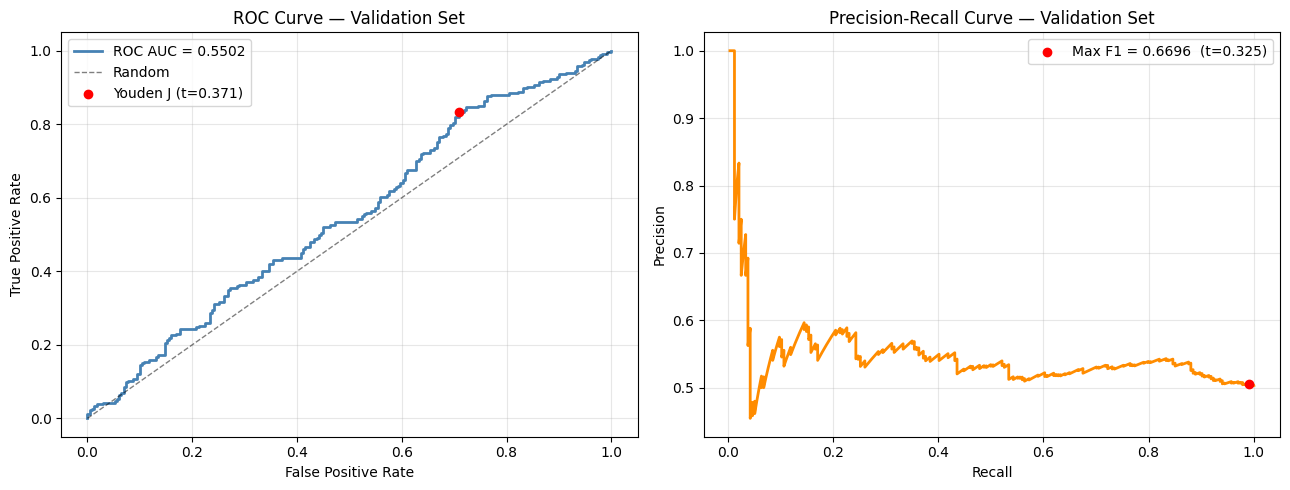

💾 Saved → roc_pr_curves_val.png

--- Threshold Selection ---
   Youden J threshold  : 0.3710
   Max F1  threshold   : 0.3247
   ➡️  SELECTED: 0.3247  (method: Max F1 (validation set))


In [25]:
# ============================================================
#  C1 — ROC & Precision-Recall Curves (Validation Set)
#
#  Two complementary curve types:
#
#  ROC curve (TPR vs FPR):
#    Measures the model's ability to discriminate UP from DOWN
#    across all thresholds. AUC ≈ 0.5 = random, 1.0 = perfect.
#    The Youden J statistic (TPR − FPR) maximises the sum of
#    sensitivity + specificity — good for balanced classes.
#
#  Precision-Recall curve:
#    More informative when class distribution is skewed.
#    The threshold that maximises F1 is found here.
#    Higher precision = fewer false UP signals.
#    Higher recall    = fewer missed UP days.
#
#  DECISION: We select the threshold from the VALIDATION SET
#  using the method that best fits the intended use case:
#    - Max F1:      balanced precision/recall (recommended default)
#    - Youden J:    balanced sensitivity/specificity
#    - Custom:      set CUSTOM_THRESHOLD to a float to override
# ============================================================

CUSTOM_THRESHOLD = None   # Set to e.g. 0.55 to override auto selection

# ROC
fpr_v, tpr_v, thresh_roc_v = roc_curve(y_val, y_val_prob)
auc_roc_v = auc(fpr_v, tpr_v)
j_idx     = np.argmax(tpr_v - fpr_v)
thresh_youden = thresh_roc_v[j_idx]

# Precision-Recall
prec_v, rec_v, thresh_pr_v = precision_recall_curve(y_val, y_val_prob)
f1_scores_v   = 2 * prec_v[:-1] * rec_v[:-1] / (prec_v[:-1] + rec_v[:-1] + 1e-9)
f1_idx        = np.argmax(f1_scores_v)
thresh_maxf1  = thresh_pr_v[f1_idx]

# Select final threshold
if CUSTOM_THRESHOLD is not None:
    FINAL_THRESHOLD = CUSTOM_THRESHOLD
    method = 'Custom'
else:
    FINAL_THRESHOLD = float(thresh_maxf1)
    method = 'Max F1 (validation set)'

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(fpr_v, tpr_v, color='steelblue', lw=2, label=f'ROC AUC = {auc_roc_v:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.scatter(fpr_v[j_idx], tpr_v[j_idx], color='red', zorder=5,
           label=f'Youden J (t={thresh_youden:.3f})')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Validation Set'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(rec_v[:-1], prec_v[:-1], color='darkorange', lw=2)
ax.scatter(rec_v[f1_idx], prec_v[f1_idx], color='red', zorder=5,
           label=f'Max F1 = {f1_scores_v[f1_idx]:.4f}  (t={thresh_maxf1:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Validation Set'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves_val.png', dpi=130, bbox_inches='tight')
plt.show()
print('💾 Saved → roc_pr_curves_val.png')

print(f'\n--- Threshold Selection ---')
print(f'   Youden J threshold  : {thresh_youden:.4f}')
print(f'   Max F1  threshold   : {thresh_maxf1:.4f}')
print(f'   ➡️  SELECTED: {FINAL_THRESHOLD:.4f}  (method: {method})')

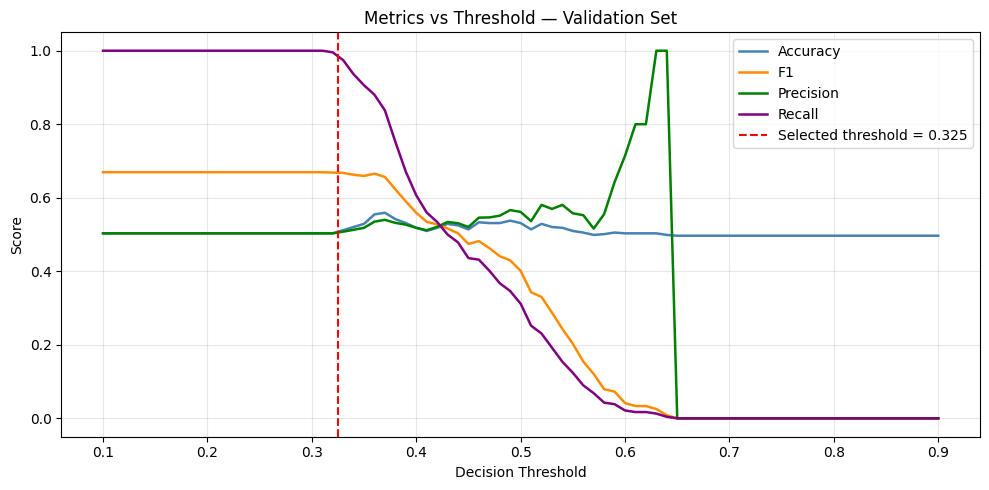

💾 Saved → metrics_vs_threshold.png


In [26]:
# ============================================================
#  C2 — F1 / Accuracy / Precision / Recall vs Threshold Plot
#
#  Shows how each metric varies across thresholds on the
#  validation set. Confirms that the selected threshold is
#  at a sensible operating point and not at an extreme.
# ============================================================

thresholds = np.linspace(0.1, 0.9, 81)
metrics_vs_thresh = {'accuracy': [], 'f1': [], 'precision': [], 'recall': []}

for t in thresholds:
    preds = (y_val_prob >= t).astype(int)
    metrics_vs_thresh['accuracy'].append(accuracy_score(y_val, preds))
    metrics_vs_thresh['f1'].append(f1_score(y_val, preds, zero_division=0))
    from sklearn.metrics import precision_score, recall_score
    metrics_vs_thresh['precision'].append(precision_score(y_val, preds, zero_division=0))
    metrics_vs_thresh['recall'].append(recall_score(y_val, preds, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'accuracy': 'steelblue', 'f1': 'darkorange', 'precision': 'green', 'recall': 'purple'}
for metric, vals in metrics_vs_thresh.items():
    ax.plot(thresholds, vals, label=metric.capitalize(), color=colors[metric], lw=1.8)
ax.axvline(FINAL_THRESHOLD, color='red', linestyle='--', lw=1.5,
           label=f'Selected threshold = {FINAL_THRESHOLD:.3f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold — Validation Set')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('metrics_vs_threshold.png', dpi=130, bbox_inches='tight')
plt.show()
print('💾 Saved → metrics_vs_threshold.png')

### Part D: Final Test Set Evaluation (One-Shot)


In [27]:
# ============================================================
#  D1 — Test Set Evaluation with Selected Threshold
#
#  This is the final, unbiased performance report.
#  The model, the threshold, all hyperparameters, and the
#  feature set were fixed before this cell runs.
#
#  Interpretation guide:
#    Accuracy > 52-53%  : consistently better than random on
#                         directional bets — tradeable edge
#    AUC > 0.55         : model has real discriminative power
#    Precision (UP)     : fraction of predicted UPs that were UP
#    Recall (UP)        : fraction of true UPs that were caught
# ============================================================

y_test_pred_default = (y_test_prob >= 0.50).astype(int)
y_test_pred_optimal = (y_test_prob >= FINAL_THRESHOLD).astype(int)

test_auc_roc = roc_auc_score(y_test, y_test_prob)

def _metrics(y_true, y_pred, y_prob, label):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    auc_v = roc_auc_score(y_true, y_prob)
    print(f'   [{label}]')
    print(f'     Accuracy  : {acc:.4f}  ({acc:.2%})')
    print(f'     AUC-ROC   : {auc_v:.4f}')
    print(f'     F1 (UP=1) : {f1:.4f}')
    return acc, f1, auc_v

print('=== FINAL TEST SET EVALUATION ===')
print(f'   Test range : {meta["test_date_range"]}')
print(f'   Samples    : {len(y_test):,}')
print()
_metrics(y_test, y_test_pred_default, y_test_prob, 'Threshold = 0.50 (default)')
print()
_metrics(y_test, y_test_pred_optimal, y_test_prob, f'Threshold = {FINAL_THRESHOLD:.3f} (optimised on val)')

print(f'\n--- Classification Report (optimal threshold) ---')
print(classification_report(y_test.astype(int), y_test_pred_optimal,
                             target_names=['DOWN (0)', 'UP (1)']))

=== FINAL TEST SET EVALUATION ===
   Test range : ('2023-01-03', '2025-03-14')
   Samples    : 510

   [Threshold = 0.50 (default)]
     Accuracy  : 0.4980  (49.80%)
     AUC-ROC   : 0.4875
     F1 (UP=1) : 0.4286

   [Threshold = 0.325 (optimised on val)]
     Accuracy  : 0.5490  (54.90%)
     AUC-ROC   : 0.4875
     F1 (UP=1) : 0.7089

--- Classification Report (optimal threshold) ---
              precision    recall  f1-score   support

    DOWN (0)       0.00      0.00      0.00       230
      UP (1)       0.55      1.00      0.71       280

    accuracy                           0.55       510
   macro avg       0.27      0.50      0.35       510
weighted avg       0.30      0.55      0.39       510



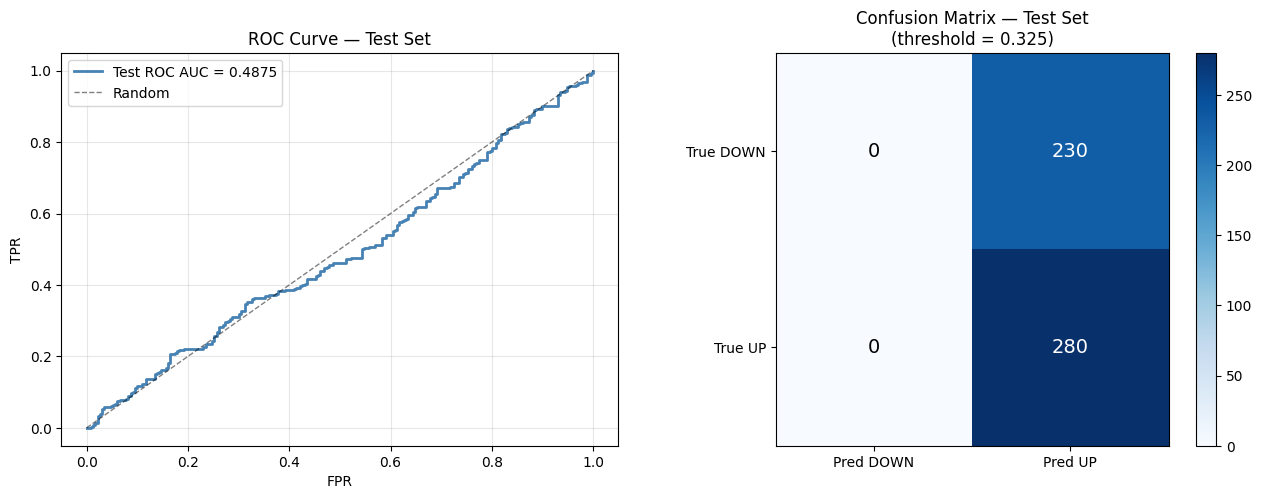

💾 Saved → test_roc_and_confusion.png


In [29]:
# ============================================================
#  D2 — Test Set ROC Curve & Confusion Matrix
# ============================================================

fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob)
auc_roc_t = auc(fpr_t, tpr_t)
cm_test   = confusion_matrix(y_test.astype(int), y_test_pred_optimal)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
ax = axes[0]
ax.plot(fpr_t, tpr_t, color='steelblue', lw=2, label=f'Test ROC AUC = {auc_roc_t:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve — Test Set'); ax.legend(); ax.grid(alpha=0.3)

# Confusion matrix
ax = axes[1]
im = ax.imshow(cm_test, cmap='Blues')
labels_cm = ['DOWN (0)', 'UP (1)']
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred DOWN', 'Pred UP'], fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(['True DOWN', 'True UP'], fontsize=10)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_test[i,j]:,}', ha='center', va='center', fontsize=14,
                color='white' if cm_test[i,j] > cm_test.max()/2 else 'black')
ax.set_title(f'Confusion Matrix — Test Set\n(threshold = {FINAL_THRESHOLD:.3f})')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('test_roc_and_confusion.png', dpi=130, bbox_inches='tight')
plt.show()
print('💾 Saved → test_roc_and_confusion.png')

### Part E: Temporal Performance Analysis


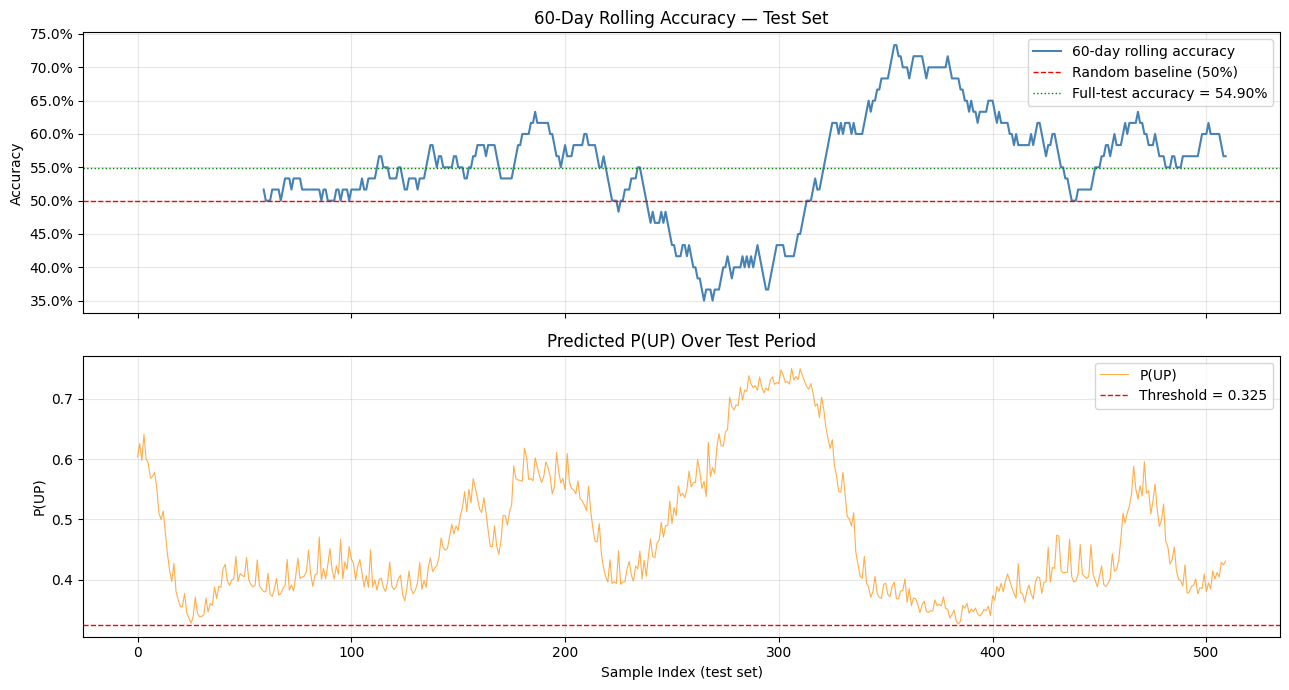

💾 Saved → temporal_performance_analysis.png


In [30]:
# ============================================================
#  E1 — Rolling Accuracy Over Test Period
#
#  A static accuracy number hides *when* the model was right
#  vs wrong. This cell computes a 60-day rolling accuracy
#  over the test window to reveal:
#    - Clusters of errors (model struggling in a regime shift)
#    - Periods of strong performance
#    - Whether performance degrades toward end of test period
#
#  We reconstruct approximate test dates from the Chapter 2A
#  meta. If the original date index isn't available, we fall
#  back to ordinal sample numbers.
# ============================================================

test_start_str = meta['test_date_range'][0]

# Build a sample-level DataFrame
df_test_perf = pd.DataFrame({
    'true'    : y_test.astype(int),
    'pred'    : y_test_pred_optimal,
    'prob'    : y_test_prob,
    'correct' : (y_test_pred_optimal == y_test.astype(int)).astype(int),
})

ROLLING_WINDOW = 60
df_test_perf['rolling_acc'] = df_test_perf['correct'].rolling(ROLLING_WINDOW).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(df_test_perf.index, df_test_perf['rolling_acc'],
        color='steelblue', lw=1.5, label=f'{ROLLING_WINDOW}-day rolling accuracy')
ax.axhline(0.5, color='red', linestyle='--', lw=1, label='Random baseline (50%)')
ax.axhline(df_test_perf['correct'].mean(), color='green', linestyle=':', lw=1,
           label=f'Full-test accuracy = {df_test_perf["correct"].mean():.2%}')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel('Accuracy')
ax.set_title(f'{ROLLING_WINDOW}-Day Rolling Accuracy — Test Set')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(df_test_perf.index, df_test_perf['prob'],
        color='darkorange', lw=0.8, alpha=0.7, label='P(UP)')
ax.axhline(FINAL_THRESHOLD, color='red', linestyle='--', lw=1,
           label=f'Threshold = {FINAL_THRESHOLD:.3f}')
ax.set_ylabel('P(UP)'); ax.set_xlabel('Sample Index (test set)')
ax.set_title('Predicted P(UP) Over Test Period')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_performance_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('💾 Saved → temporal_performance_analysis.png')

--- Accuracy by Confidence Tier ---
                 tier  n_samples  accuracy  mean_prob
 Low (|p−0.5| < 0.10)        271  0.523985   0.477153
      Mid (0.10–0.20)        203  0.576355   0.412938
High (|p−0.5| ≥ 0.20)         36  0.583333   0.725583


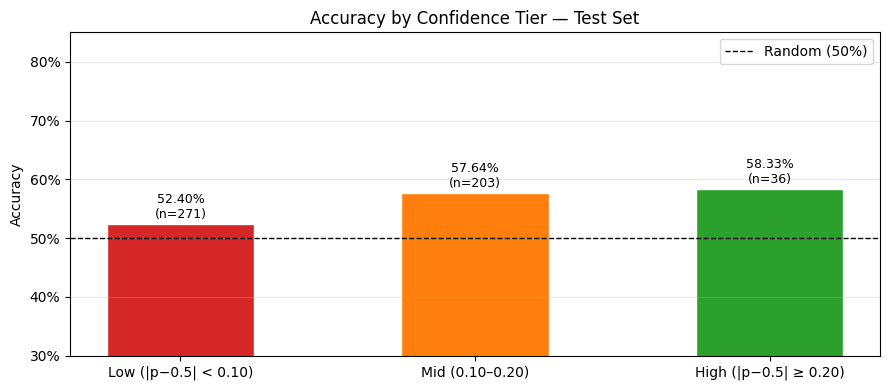

💾 Saved → accuracy_by_confidence_tier.png


In [31]:
# ============================================================
#  E2 — Performance by Prediction Confidence Tier
#
#  Splits test predictions into confidence buckets:
#    Low  : |P(UP) − 0.5| < 0.1   (near-borderline, avoid these)
#    Mid  : 0.1 ≤ |P(UP) − 0.5| < 0.2
#    High : |P(UP) − 0.5| ≥ 0.2   (high conviction calls)
#
#  In a real trading context, you would only trade 'High'
#  confidence signals. This analysis shows whether the model's
#  confidence is calibrated — i.e., high-confidence calls
#  should indeed have higher accuracy.
# ============================================================

df_test_perf['confidence'] = (df_test_perf['prob'] - 0.5).abs()

bins   = [0, 0.1, 0.2, 1.0]
labels = ['Low (|p−0.5| < 0.10)', 'Mid (0.10–0.20)', 'High (|p−0.5| ≥ 0.20)']
df_test_perf['tier'] = pd.cut(df_test_perf['confidence'], bins=bins, labels=labels)

tier_summary = df_test_perf.groupby('tier', observed=True).agg(
    n_samples=('correct', 'count'),
    accuracy=('correct', 'mean'),
    mean_prob=('prob', 'mean'),
).reset_index()

print('--- Accuracy by Confidence Tier ---')
print(tier_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors_tier = ['#d62728', '#ff7f0e', '#2ca02c']
bars = ax.bar(tier_summary['tier'].astype(str), tier_summary['accuracy'],
              color=colors_tier, edgecolor='white', width=0.5)
for bar, row in zip(bars, tier_summary.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{row.accuracy:.2%}\n(n={row.n_samples:,})',
            ha='center', va='bottom', fontsize=9)
ax.axhline(0.5, color='black', linestyle='--', lw=1, label='Random (50%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0.3, 0.85)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Confidence Tier — Test Set')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_by_confidence_tier.png', dpi=130, bbox_inches='tight')
plt.show()
print('💾 Saved → accuracy_by_confidence_tier.png')

### Part F: Feature Importance via Gradient Saliency


In [32]:
# ============================================================
#  F1 — Gradient-Based Feature Importance (GradientTape)
#
#  For each test sample, we compute the gradient of the output
#  neuron with respect to each input feature-timestep.
#  The magnitude of the gradient tells us how sensitive the
#  prediction is to a small change in that feature at that
#  timestep. Averaging across samples and taking the L2-norm
#  over the time axis gives a per-feature importance score.
#
#  This is the simplest and most reliable explainability
#  method for temporal models — no external dependency required.
#  More sophisticated alternatives (SHAP, Integrated Gradients)
#  can be explored in future work.
#
#  We process in batches to avoid OOM on large test sets.
# ============================================================

print('⏳ Computing gradient saliency (this may take ~1-2 minutes)...')

SALIENCY_BATCH = 128
n_test = len(X_test)
# Shape: (n_test, window_size, n_features)
all_grads = np.zeros((n_test, WINDOW_SIZE, N_FEATURES), dtype=np.float32)

for start in range(0, n_test, SALIENCY_BATCH):
    end     = min(start + SALIENCY_BATCH, n_test)
    x_batch = tf.constant(X_test[start:end], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x_batch)
        preds = model(x_batch, training=False)
    grads = tape.gradient(preds, x_batch)  # (batch, window, features)
    all_grads[start:end] = grads.numpy()

# Per-feature importance: mean absolute gradient over time and samples
feature_importance = np.abs(all_grads).mean(axis=(0, 1))   # (n_features,)
feature_importance = feature_importance / feature_importance.sum()  # normalise to sum=1

importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print('✅ Saliency computation complete!')
print('\n--- Feature Importance Ranking ---')
for _, row in importance_df.iterrows():
    bar = '█' * int(row['importance'] * 200)
    print(f'   {row["feature"]:<22} {row["importance"]*100:5.2f}%  {bar}')

⏳ Computing gradient saliency (this may take ~1-2 minutes)...
✅ Saliency computation complete!

--- Feature Importance Ranking ---
   macd_hist              10.31%  ████████████████████
   macd                    7.42%  ██████████████
   ma5_dist                6.94%  █████████████
   atr14                   6.68%  █████████████
   obv_change              6.55%  █████████████
   bb_position             6.54%  █████████████
   bb_width                6.47%  ████████████
   day_of_week             6.02%  ████████████
   ma_cross_strength       5.99%  ███████████
   return                  5.92%  ███████████
   volume                  5.69%  ███████████
   signal                  5.36%  ██████████
   volume_change           5.31%  ██████████
   rsi14                   5.10%  ██████████
   body_ratio              4.93%  █████████
   ma20_dist               4.76%  █████████


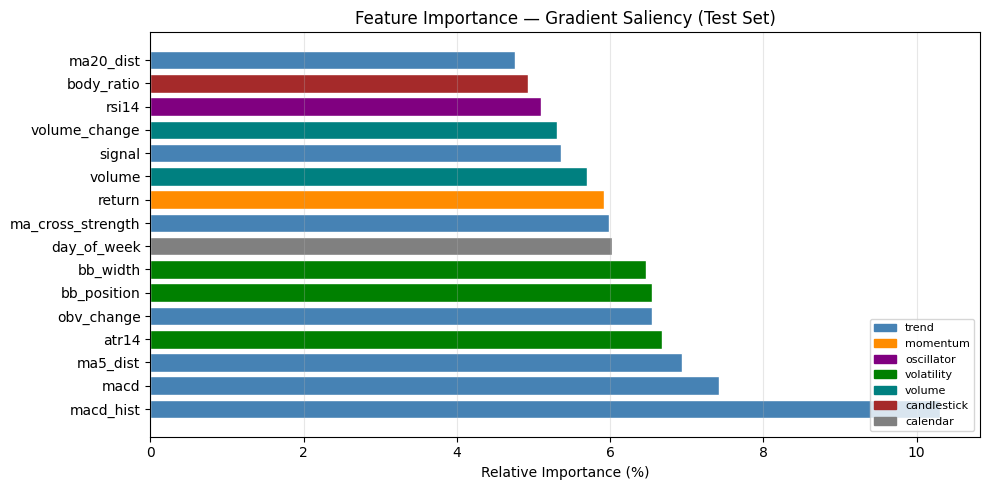

💾 Saved → feature_importance.png


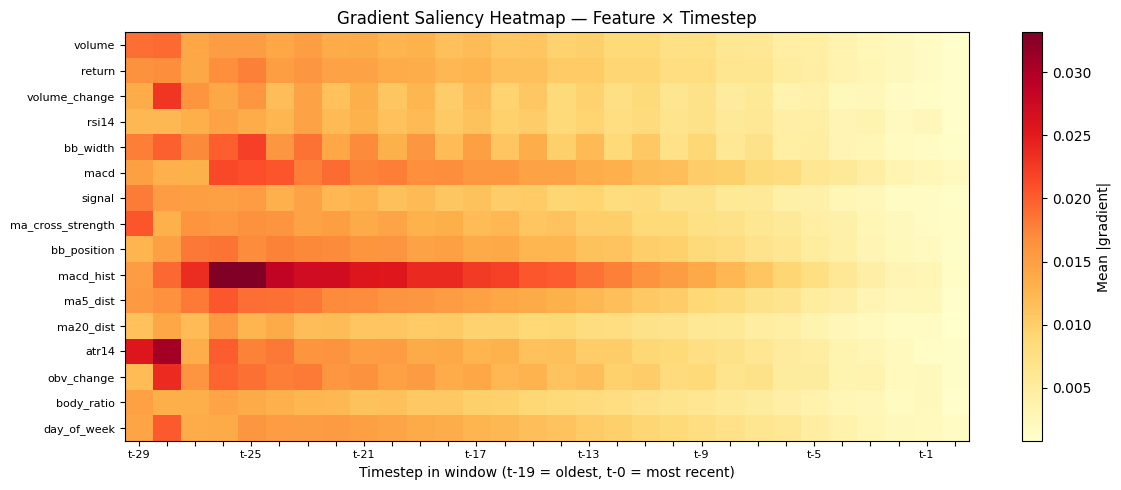

💾 Saved → saliency_heatmap.png


In [33]:
# ============================================================
#  F2 — Feature Importance Plot & Temporal Heatmap
#
#  Plot 1: Horizontal bar chart of feature importances.
#    Colour encodes feature category (price-derived, volume,
#    oscillator, calendar) for quick visual grouping.
#
#  Plot 2: Heatmap of average absolute gradient over the
#    20-timestep window for each feature. Shows WHICH
#    timesteps matter most — ideally, more recent timesteps
#    (right side) should have higher saliency.
# ============================================================

FEATURE_CATEGORIES = {
    'volume'           : 'volume',
    'ma5'              : 'trend',
    'ma20'             : 'trend',
    'ma_cross_strength': 'trend',
    'return'           : 'momentum',
    'volume_change'    : 'volume',
    'rsi14'            : 'oscillator',
    'bb_position'      : 'volatility',
    'bb_width'         : 'volatility',
    'macd'             : 'trend',
    'signal'           : 'trend',
    'macd_hist'        : 'trend',
    'atr14'            : 'volatility',
    'obv'              : 'volume',
    'body_ratio'       : 'candlestick',
    'day_of_week'      : 'calendar',
}
CAT_COLORS = {
    'trend': 'steelblue', 'momentum': 'darkorange', 'oscillator': 'purple',
    'volatility': 'green', 'volume': 'teal', 'candlestick': 'brown', 'calendar': 'gray'
}

# Plot 1: Feature importance bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [CAT_COLORS.get(FEATURE_CATEGORIES.get(f, 'trend'), 'gray')
              for f in importance_df['feature']]
bars = ax.barh(importance_df['feature'], importance_df['importance'] * 100,
               color=colors_bar, edgecolor='white')
ax.set_xlabel('Relative Importance (%)')
ax.set_title('Feature Importance — Gradient Saliency (Test Set)')
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(color=v, label=k) for k, v in CAT_COLORS.items()
                   if k in FEATURE_CATEGORIES.values()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print('💾 Saved → feature_importance.png')

# Plot 2: Temporal saliency heatmap
# Mean absolute gradient per (timestep, feature), averaged over test samples
saliency_map = np.abs(all_grads).mean(axis=0)  # (window_size, n_features)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(saliency_map.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xticks(range(WINDOW_SIZE))
ax.set_xticklabels([f't-{WINDOW_SIZE-1-i}' if i % 4 == 0 else ''
                    for i in range(WINDOW_SIZE)], fontsize=8)
ax.set_yticks(range(N_FEATURES))
ax.set_yticklabels(FEATURE_COLS, fontsize=8)
ax.set_xlabel('Timestep in window (t-19 = oldest, t-0 = most recent)')
ax.set_title('Gradient Saliency Heatmap — Feature × Timestep')
plt.colorbar(im, ax=ax, label='Mean |gradient|')
plt.tight_layout()
plt.savefig('saliency_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('💾 Saved → saliency_heatmap.png')

### Part G: Final Summary Report & Save All Artifacts


In [34]:
# ============================================================
#  G1 — Final Performance Summary
#
#  Prints a clean summary card suitable for reporting or
#  including in the project README.
# ============================================================

test_acc_optimal  = accuracy_score(y_test.astype(int), y_test_pred_optimal)
test_acc_default  = accuracy_score(y_test.astype(int), y_test_pred_default)
test_f1_optimal   = f1_score(y_test.astype(int), y_test_pred_optimal, zero_division=0)
test_auc_roc_val  = auc_roc_v

top3_features = importance_df.head(3)['feature'].tolist()

print('=' * 60)
print('   CNN + LSTM STOCK DIRECTION PREDICTOR — FINAL RESULTS')
print('=' * 60)
print(f'   Ticker          : AAPL')
print(f'   Test period     : {meta["test_date_range"][0]} → {meta["test_date_range"][1]}')
print(f'   Test samples    : {len(y_test):,}')
print()
print('   ── Training Performance ──────────────────────────')
print(f'   Best epoch      : {cfg["best_epoch"]}')
print(f'   Best val AUC    : {cfg["best_val_auc"]:.4f}')
print(f'   Best val acc    : {cfg["val_accuracy"]:.4f}  ({cfg["val_accuracy"]:.2%})')
print()
print('   ── Test Performance (one-shot) ───────────────────')
print(f'   AUC-ROC         : {test_auc_roc:.4f}')
print(f'   Accuracy (t=0.5): {test_acc_default:.4f}  ({test_acc_default:.2%})')
print(f'   Accuracy (t={FINAL_THRESHOLD:.2f}): {test_acc_optimal:.4f}  ({test_acc_optimal:.2%})')
print(f'   F1 (UP, t={FINAL_THRESHOLD:.2f}) : {test_f1_optimal:.4f}')
print()
print('   ── Model Configuration ───────────────────────────')
print(f'   Window size     : {WINDOW_SIZE} days')
print(f'   Features        : {N_FEATURES}  ({FEATURE_COLS})')
print(f'   CNN filters     : {HP["FILTERS_1"]} → {HP["FILTERS_2"]}')
print(f'   LSTM units      : {HP["LSTM_UNITS_1"]} → {HP["LSTM_UNITS_2"]}')
print(f'   Total params    : {model.count_params():,}')
print()
print(f'   ── Top-3 Important Features ──────────────────────')
for i, feat in enumerate(top3_features, 1):
    imp = importance_df.loc[importance_df['feature'] == feat, 'importance'].values[0]
    print(f'   {i}. {feat:<22}  ({imp*100:.2f}%)')
print('=' * 60)

   CNN + LSTM STOCK DIRECTION PREDICTOR — FINAL RESULTS
   Ticker          : AAPL
   Test period     : 2023-01-03 → 2025-03-14
   Test samples    : 510

   ── Training Performance ──────────────────────────
   Best epoch      : 15
   Best val AUC    : 0.5495
   Best val acc    : 0.5312  (53.12%)

   ── Test Performance (one-shot) ───────────────────
   AUC-ROC         : 0.4875
   Accuracy (t=0.5): 0.4980  (49.80%)
   Accuracy (t=0.32): 0.5490  (54.90%)
   F1 (UP, t=0.32) : 0.7089

   ── Model Configuration ───────────────────────────
   Window size     : 30 days
   Features        : 16  (['volume', 'return', 'volume_change', 'rsi14', 'bb_width', 'macd', 'signal', 'ma_cross_strength', 'bb_position', 'macd_hist', 'ma5_dist', 'ma20_dist', 'atr14', 'obv_change', 'body_ratio', 'day_of_week'])
   CNN filters     : 32 → 64
   LSTM units      : 64 → 64
   Total params    : 161,121

   ── Top-3 Important Features ──────────────────────
   1. macd_hist               (10.31%)
   2. macd          

In [35]:
# ============================================================
#  G2 — Save All Chapter 2C Artifacts
# ============================================================

np.save('test_predictions_prob.npy',    y_test_prob)
np.save('test_predictions_binary.npy',  y_test_pred_optimal)
np.save('feature_saliency.npy',         feature_importance)
np.save('saliency_map_full.npy',        saliency_map)

importance_df.to_csv('feature_importance.csv', index=False)

final_results = {
    'test_auc_roc'         : float(test_auc_roc),
    'test_accuracy_default': float(test_acc_default),
    'test_accuracy_optimal': float(test_acc_optimal),
    'test_f1_optimal'      : float(test_f1_optimal),
    'final_threshold'      : float(FINAL_THRESHOLD),
    'threshold_method'     : method,
    'val_auc_roc'          : float(test_auc_roc_val),
    'best_epoch'           : cfg['best_epoch'],
    'best_val_auc'         : cfg['best_val_auc'],
    'top3_features'        : top3_features,
    'feature_importance_df': importance_df.to_dict('records'),
    'training_config'      : cfg,
    'preprocessing_meta'   : meta,
}
with open('final_results.pkl', 'wb') as f:
    pickle.dump(final_results, f)

SAVED = [
    'test_predictions_prob.npy',
    'test_predictions_binary.npy',
    'feature_saliency.npy',
    'saliency_map_full.npy',
    'feature_importance.csv',
    'final_results.pkl',
    'predicted_probability_distributions.png',
    'roc_pr_curves_val.png',
    'metrics_vs_threshold.png',
    'test_roc_and_confusion.png',
    'temporal_performance_analysis.png',
    'accuracy_by_confidence_tier.png',
    'feature_importance.png',
    'saliency_heatmap.png',
]

print('✅ All Chapter 2C artifacts saved:')
for fname in SAVED:
    print(f'   💾  {fname}')

print(f'\n{"="*56}')
print(f'  Chapter 2C complete — evaluation pipeline done.')
print(f'  Test AUC   : {test_auc_roc:.4f}')
print(f'  Test Acc   : {test_acc_optimal:.4f}  (threshold={FINAL_THRESHOLD:.3f})')
print(f'{"="*56}')

✅ All Chapter 2C artifacts saved:
   💾  test_predictions_prob.npy
   💾  test_predictions_binary.npy
   💾  feature_saliency.npy
   💾  saliency_map_full.npy
   💾  feature_importance.csv
   💾  final_results.pkl
   💾  predicted_probability_distributions.png
   💾  roc_pr_curves_val.png
   💾  metrics_vs_threshold.png
   💾  test_roc_and_confusion.png
   💾  temporal_performance_analysis.png
   💾  accuracy_by_confidence_tier.png
   💾  feature_importance.png
   💾  saliency_heatmap.png

  Chapter 2C complete — evaluation pipeline done.
  Test AUC   : 0.4875
  Test Acc   : 0.5490  (threshold=0.325)
